<a href="https://colab.research.google.com/github/carolonias-lgtm/Cen/blob/main/tarefa07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-Carolina Ferreira Onias 16859769

-Luciana Miki Sumi 16885456

-Melissa Rebechi Santana 17015126


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("fisico-quimicas.csv")

In [12]:
from google.colab import files

uploaded = files.upload()

Saving fisico-quimicas.csv to fisico-quimicas (1).csv


In [13]:
df = pd.read_csv("fisico-quimicas.csv")


In [14]:
df.head()

,Amostra,Categoria,Solidos_Soluveis_Brix,Acucar_g_100g,pH,Acidez_g_100mL,Acucar_estimado
0,A27,Frutas,14.12,9.42,2.86,0.65,8.706996
1,A05,Sucos e bebidas,10.02,7.17,2.83,0.79,5.552567
2,A60,Néctares e polpas,13.41,5.10,3.03,0.88,8.160741
3,A41,Néctares e polpas,23.37,15.14,2.90,0.45,15.823696
4,A10,Sucos e bebidas,7.71,5.05,2.99,0.79,3.775315


In [18]:
df["Categoria"].unique()

array(['Frutas', 'Sucos e bebidas', 'Néctares e polpas'], dtype=object)

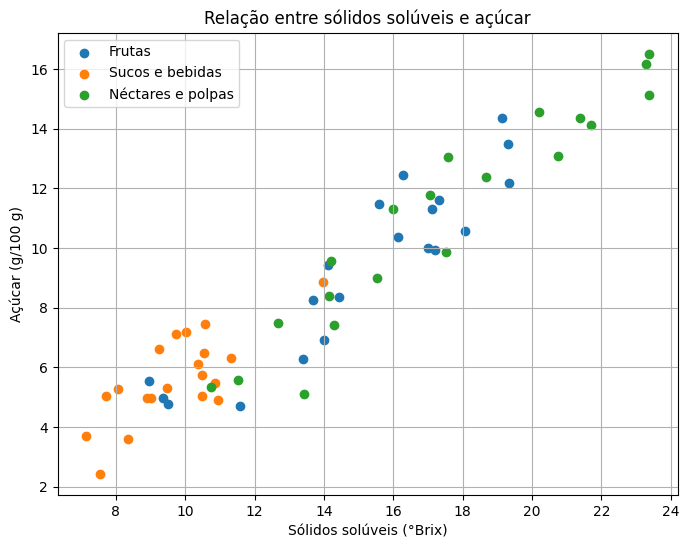

In [19]:
plt.figure(figsize=(8,6))

for categoria in df["Categoria"].unique():
    dados = df[df["Categoria"] == categoria]

    plt.scatter(
        dados["Solidos_Soluveis_Brix"],
        dados["Acucar_g_100g"],
        label=categoria
    )

plt.xlabel("Sólidos solúveis (°Brix)")
plt.ylabel("Açúcar (g/100 g)")
plt.title("Relação entre sólidos solúveis e açúcar")
plt.legend()
plt.grid(True)

plt.show()

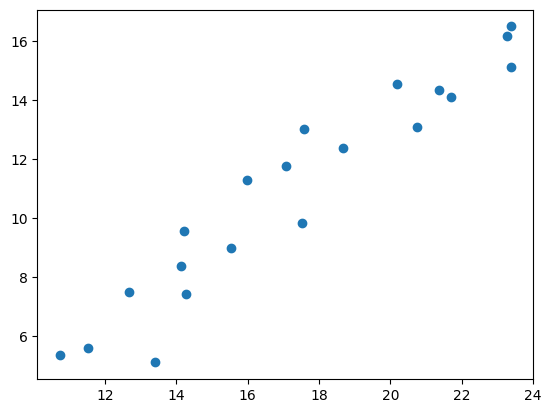

In [20]:
plt.scatter(
    dados["Solidos_Soluveis_Brix"],
    dados["Acucar_g_100g"]
)

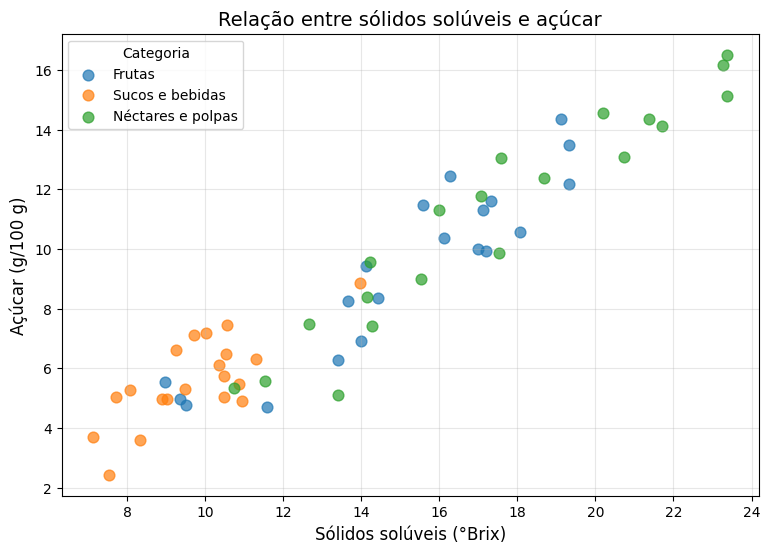

In [22]:
plt.figure(figsize=(9,6))

for categoria in df["Categoria"].unique():
    dados = df[df["Categoria"] == categoria]

    plt.scatter(
        dados["Solidos_Soluveis_Brix"],
        dados["Acucar_g_100g"],
        label=categoria,
        s=60,
        alpha=0.7
    )

plt.xlabel("Sólidos solúveis (°Brix)", fontsize=12)
plt.ylabel("Açúcar (g/100 g)", fontsize=12)
plt.title("Relação entre sólidos solúveis e açúcar", fontsize=14)

plt.legend(title="Categoria")
plt.grid(alpha=0.3)

plt.show()

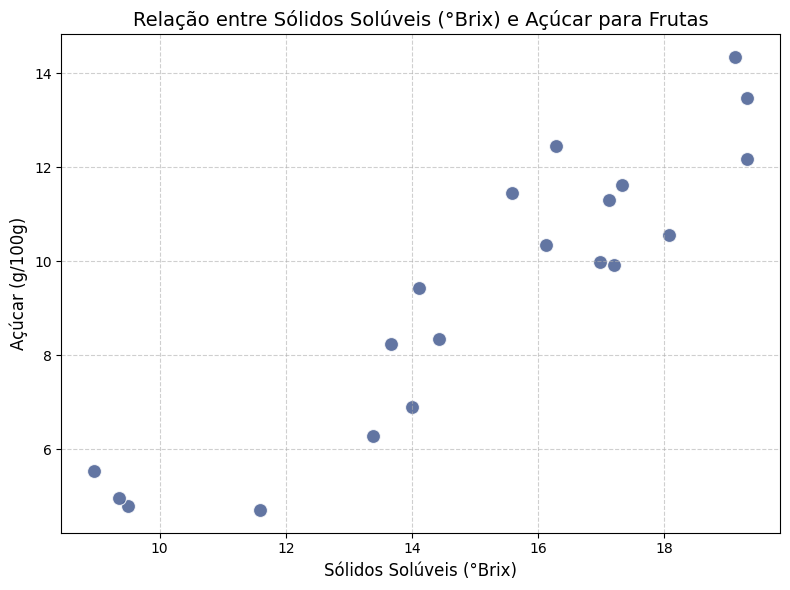

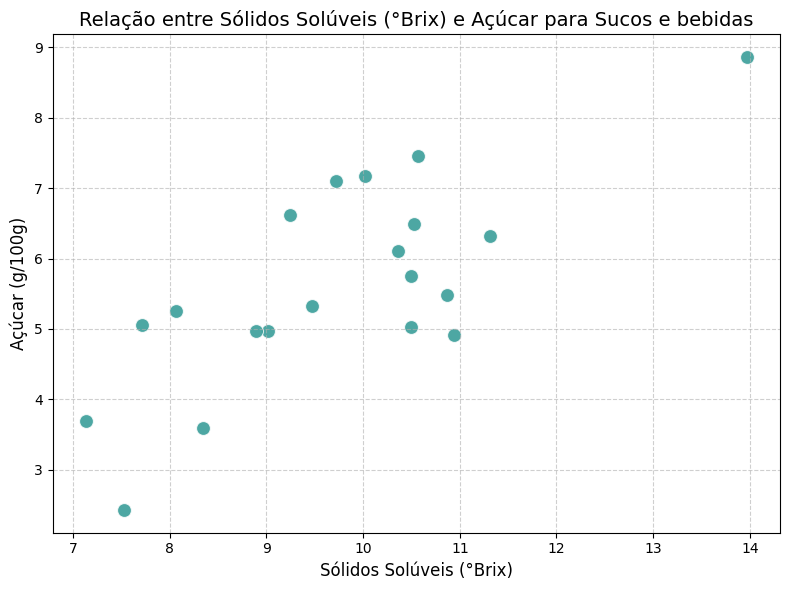

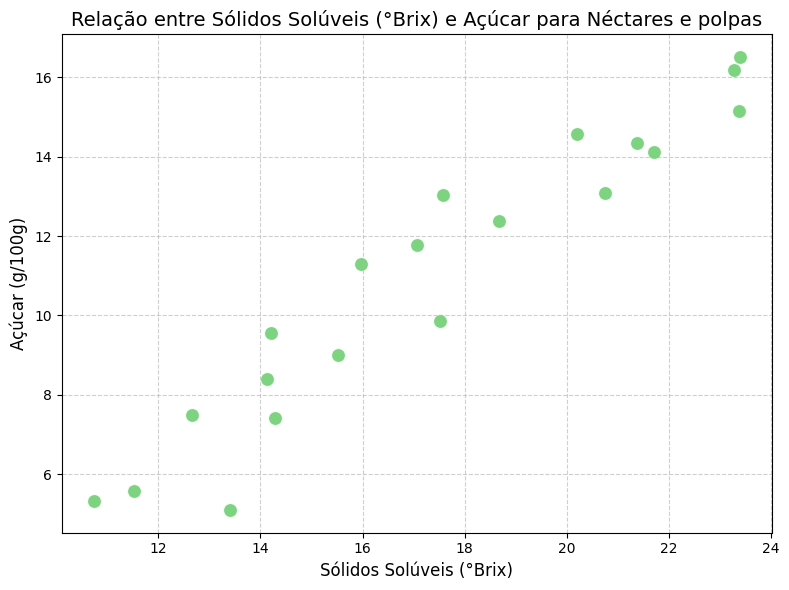

In [24]:
import seaborn as sns

# Define a color palette for the categories
palette = sns.color_palette("viridis", n_colors=len(df['Categoria'].unique()))

for i, categoria in enumerate(df['Categoria'].unique()):
    # Filter data for the current category
    df_categoria = df[df['Categoria'] == categoria]

    # Create a new figure for each plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_categoria,
        x='Solidos_Soluveis_Brix',
        y='Acucar_g_100g',
        s=100, # Adjust marker size
        alpha=0.8, # Adjust transparency
        color=palette[i] # Assign a distinct color from the palette
    )

    # Add title and labels
    plt.title(f'Relação entre Sólidos Solúveis (°Brix) e Açúcar para {categoria}', fontsize=14)
    plt.xlabel('Sólidos Solúveis (°Brix)', fontsize=12)
    plt.ylabel('Açúcar (g/100g)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

### Análise de Outliers por Categoria (Método IQR)

Vamos identificar outliers para 'Solidos_Soluveis_Brix' e 'Acucar_g_100g' em cada categoria, usando o método do Intervalo Interquartil (IQR). Um ponto é considerado um outlier se estiver abaixo de `Q1 - 1.5 * IQR` ou acima de `Q3 + 1.5 * IQR`.

In [29]:
for categoria in df['Categoria'].unique():
    print(f"\n--- Categoria: {categoria} ---")
    df_categoria = df[df['Categoria'] == categoria]

    for col in ['Solidos_Soluveis_Brix', 'Acucar_g_100g']:
        Q1 = df_categoria[col].quantile(0.25)
        Q3 = df_categoria[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df_categoria[(df_categoria[col] < lower_bound) | (df_categoria[col] > upper_bound)]

        if not outliers.empty:
            print(f"Outliers para '{col}':")
            display(outliers[['Amostra', col]])
        else:
            print(f"Não foram encontrados outliers para '{col}'.")


--- Categoria: Frutas ---
Não foram encontrados outliers para 'Solidos_Soluveis_Brix'.
Não foram encontrados outliers para 'Acucar_g_100g'.

--- Categoria: Sucos e bebidas ---
Outliers para 'Solidos_Soluveis_Brix':


,Amostra,Solidos_Soluveis_Brix
24,A08,13.97


Outliers para 'Acucar_g_100g':


,Amostra,Acucar_g_100g
23,A12,2.43
24,A08,8.86



--- Categoria: Néctares e polpas ---
Não foram encontrados outliers para 'Solidos_Soluveis_Brix'.
Não foram encontrados outliers para 'Acucar_g_100g'.


In [25]:
import pandas as pd

df = pd.read_csv("fisico-quimicas.csv")

In [26]:
frutas = df[df["Categoria"] == "Frutas"]

r_frutas = frutas["Solidos_Soluveis_Brix"].corr(
    frutas["Acucar_g_100g"]
)

print(r_frutas)

0.9205458795306104


In [27]:
for categoria in df["Categoria"].unique():

    dados = df[df["Categoria"] == categoria]

    r = dados["Solidos_Soluveis_Brix"].corr(
        dados["Acucar_g_100g"]
    )

    print(categoria, ":", r)

Frutas : 0.9205458795306104
Sucos e bebidas : 0.7553307110957194
Néctares e polpas : 0.957197145117721


In [28]:
for categoria in df["Categoria"].unique():

    dados = df[df["Categoria"] == categoria]

    r = dados["Solidos_Soluveis_Brix"].corr(
        dados["Acucar_g_100g"]
    )

    print(f"{categoria}: r = {r:.3f}")

Frutas: r = 0.921
Sucos e bebidas: r = 0.755
Néctares e polpas: r = 0.957


#Relação de Sólidos soluveis (°Brix) e açúcar nas diferentes categorias
Conforme analisado os gráficos e o fator de correlação linear de Pearson das diferentes categorias, podemos concluir que sim, há uma relação positiva e forte das duas variáveis em todas as categotrias.

#Variação teor de açúcar e °Brix
Ambos aumentam juntos, eles tem uma relação de proporcionalidade, isso porque, os açúcares são parte da composição do grau brix.


#Linearidade das variáveis
Sim, pode ser considerada uma relação linear. Apenas notamos que há presença de outliers somente na categoria "Sucos e bebidas". Olhando sobre um viés analítico, essa categoria é muito ampla para ter uma conclusão definitiva, isso porque, algumas bebidas (que não foram identificadas) podem ter, em sua composição centesimal, mais de determinado compostos solúveis (que compõe o grau brix) do que açúcar, por exemplo, leite, pode ter mais proteína ou mais gordura do que açúcares, o que interferiria na média e outros dados.  

#Amostra de 15° Brix


In [32]:
#Calculo para a quantidade de açúcar caso cada cateogria tenha 15°Brix
from scipy.stats import linregress

for categoria in df["Categoria"].unique():

    dados = df[df["Categoria"] == categoria]

    resultado = linregress(
        dados["Solidos_Soluveis_Brix"],
        dados["Acucar_g_100g"]
    )

    a = resultado.intercept
    b = resultado.slope

    acucar_15_brix = a + b * 15

    print(f"{categoria}: {acucar_15_brix:.2f} g/100 g")

Frutas: 9.28 g/100 g
Sucos e bebidas: 9.31 g/100 g
Néctares e polpas: 8.97 g/100 g


In [30]:
from sklearn.linear_model import LinearRegression
import numpy as np

#°Brix é um bom medidor?
O °brix para indicar a quantidade de açúcar numa amostra será um bom medidor dependendo da natureza do alimento analisado. Por exemplo, para bebidas alcoolicas, é ótimo, pois quase não há outros contribuintes sólidos solúveis que não o açúcar. Porém, para leite e sucos/nectares/polpas (outros a base de hortifruti) pode não ser um bom medidor, porque entrarão no cálculo proteínas, ácidos, minerais, entre outros.